# Basilisk Tutorial — Visualization

This notebook visualizes the results of the three test cases:
1. **Laplace equilibrium** — pressure field and interface
2. **Drop impact** — interface evolution over time
3. **Coalescence** — bridge radius scaling and interface snapshots

> **Prerequisites:** Run the simulations first with `make all` from the project root.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# Project root (one level up from notebooks/)
ROOT = Path("..").resolve()

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## Case 1 — Laplace Pressure Equilibrium

A circular droplet at rest. We check the pressure jump $\Delta P = \sigma / R$ across the interface.

The file `pressure.dat` contains columns: `x  y  pressure  VOF_fraction`.

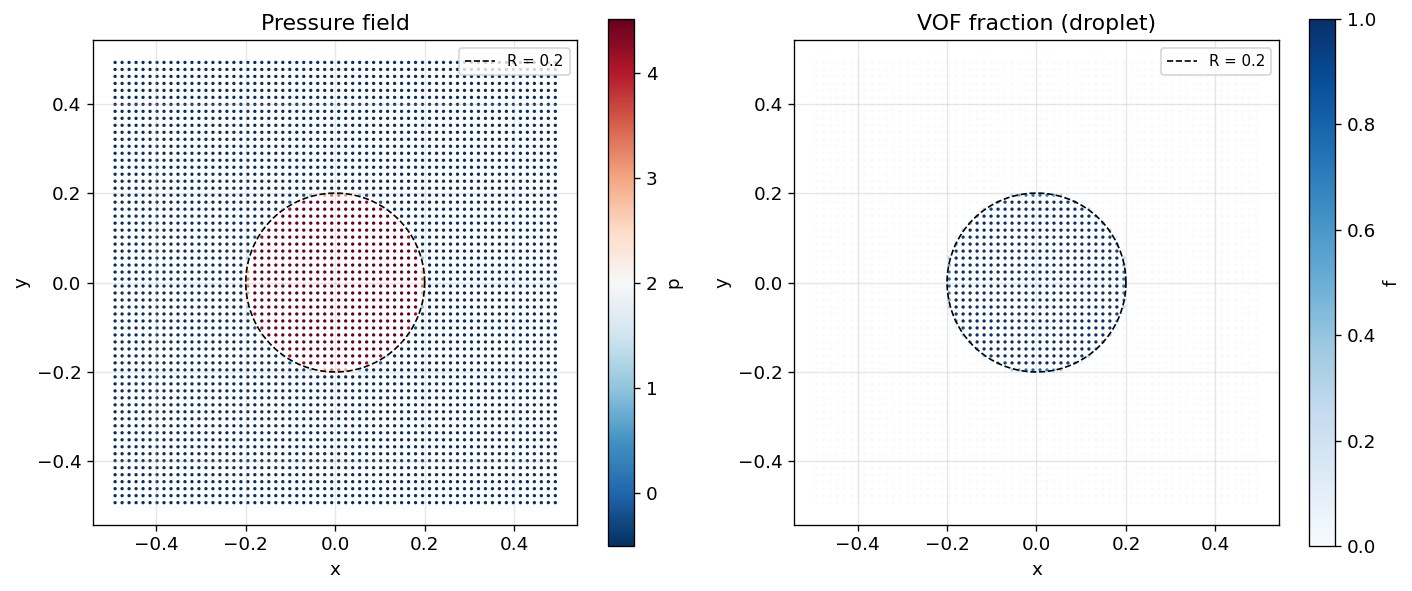

ΔP (numerical)  = 5.0074
ΔP (analytical) = 5.0000
Relative error  = 0.15%


In [18]:
data_dir = ROOT / "cases" / "01-laplace"
pfile = data_dir / "pressure.dat"

if pfile.exists():
    data = np.loadtxt(pfile)
    x, y, p, f = data[:, 0], data[:, 1], data[:, 2], data[:, 3]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Pressure field
    sc = axes[0].scatter(x, y, c=p, s=1, cmap="RdBu_r")
    axes[0].set_aspect("equal")
    axes[0].set_title("Pressure field")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(sc, ax=axes[0], label="p")

    # VOF fraction (interface)
    sc2 = axes[1].scatter(x, y, c=f, s=1, cmap="Blues", vmin=0, vmax=1)
    axes[1].set_aspect("equal")
    axes[1].set_title("VOF fraction (droplet)")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    plt.colorbar(sc2, ax=axes[1], label="f")

    # Draw analytical circle
    theta = np.linspace(0, 2 * np.pi, 200)
    R = 0.2
    for ax in axes:
        ax.plot(R * np.cos(theta), R * np.sin(theta), "k--", lw=1, label=f"R = {R}")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Pressure jump analysis
    p_inside = p[f > 0.9]
    p_outside = p[f < 0.1]
    dp = np.mean(p_inside) - np.mean(p_outside)
    dp_theory = 1.0 / R  # sigma/R with sigma=1

    print(f"ΔP (numerical)  = {dp:.4f}")
    print(f"ΔP (analytical) = {dp_theory:.4f}")
    print(f"Relative error  = {abs(dp - dp_theory) / dp_theory * 100:.2f}%")
else:
    print(f"⚠ File not found: {pfile}")
    print("  Run 'make case1' first.")

## Case 2 — Drop Impact

Axisymmetric droplet impacting a solid surface. Interface snapshots at different times.

Files: `interface-XX.XX.dat` — each file contains line segments of the VOF interface.

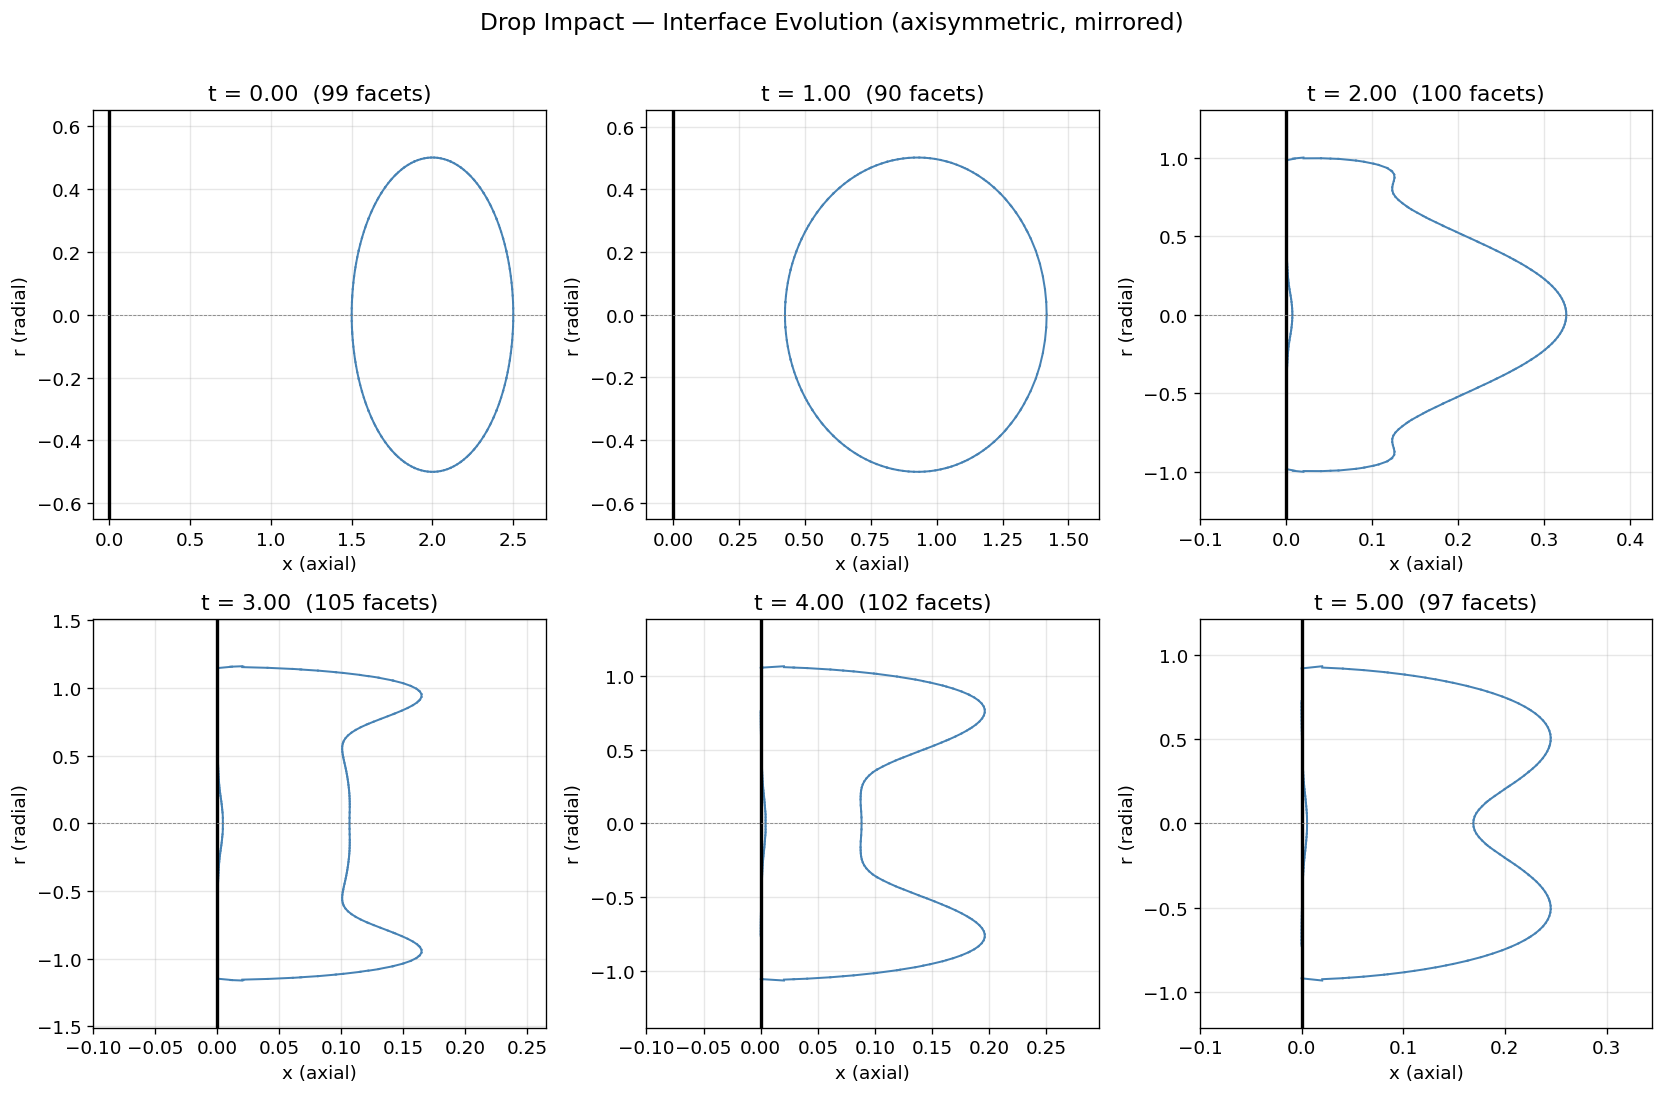

In [19]:
def load_facets(filepath):
    """Load Basilisk output_facets data (segments separated by blank lines)."""
    segments = []
    current = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                if current:
                    segments.append(np.array(current))
                    current = []
            else:
                try:
                    current.append([float(v) for v in line.split()])
                except ValueError:
                    pass
    if current:
        segments.append(np.array(current))
    return segments


data_dir = ROOT / "cases" / "02-drop-impact"
files = sorted(data_dir.glob("interface-*.dat"))

if files:
    # Select up to 6 snapshots evenly spaced
    indices = np.linspace(0, len(files) - 1, min(6, len(files)), dtype=int)
    selected = [files[i] for i in indices]

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flatten()

    for idx, (ax, fpath) in enumerate(zip(axes, selected)):
        segments = load_facets(fpath)

        # Collect all points for auto-scaling
        all_x, all_y = [], []
        for seg in segments:
            if seg.shape[0] >= 2:
                ax.plot(seg[:, 0], seg[:, 1], "steelblue", lw=1.2)
                ax.plot(seg[:, 0], -seg[:, 1], "steelblue", lw=1.2)
                all_x.extend(seg[:, 0])
                all_y.extend(seg[:, 1])

        # Draw the wall at x = 0
        ax.axvline(x=0, color="k", lw=2)
        ax.axhline(y=0, color="gray", lw=0.5, ls="--")

        # Auto-scale with margin around the data
        if all_x:
            xmin, xmax = min(all_x), max(all_x)
            ymax = max(all_y)
            margin_x = max(0.1, (xmax - xmin) * 0.2)
            margin_y = max(0.1, ymax * 0.3)
            ax.set_xlim(-0.1, xmax + margin_x)
            ax.set_ylim(-(ymax + margin_y), ymax + margin_y)

        t_label = fpath.stem.replace("interface-", "t = ")
        ax.set_title(f"{t_label}  ({len(segments)} facets)")
        ax.set_xlabel("x (axial)")
        ax.set_ylabel("r (radial)")
        # ax.set_aspect("equal")

    for ax in axes[len(selected):]:
        ax.set_visible(False)

    fig.suptitle("Drop Impact — Interface Evolution (axisymmetric, mirrored)",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ No interface files found in {data_dir}")
    print("  Run 'make case2' first.")

## Case 3 — Coalescence of Two Droplets

Two droplets merge under surface tension. We track the capillary bridge radius $r_b$ and compare to the inertial scaling $r_b \sim t^{1/2}$.

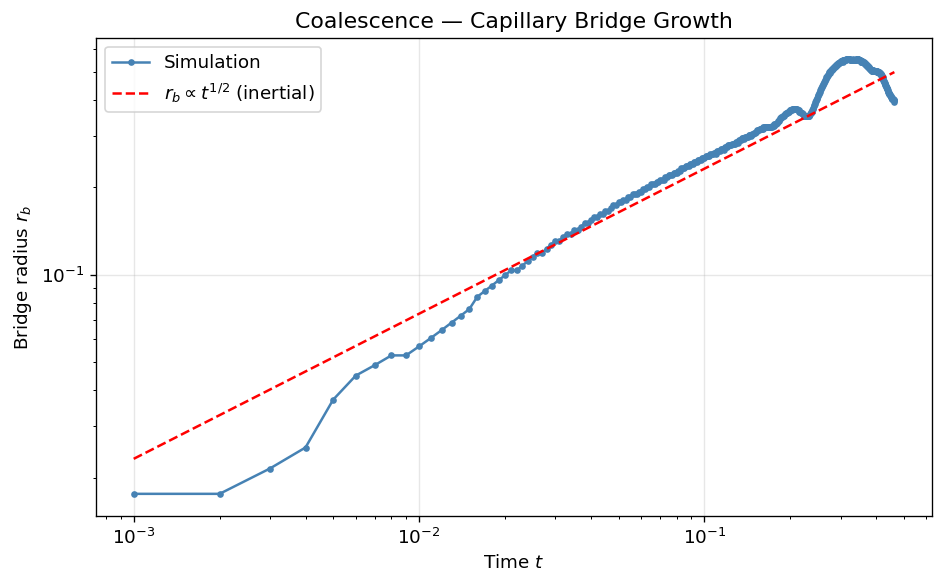

In [20]:
data_dir = ROOT / "cases" / "03-coalescence"

# --- Bridge radius vs time ---
bridge_file = data_dir / "bridge.dat"

if bridge_file.exists():
    bdata = np.loadtxt(bridge_file)
    t_b, rb = bdata[:, 0], bdata[:, 1]

    # Filter out t=0 for log scale
    mask = t_b > 0
    t_b, rb = t_b[mask], rb[mask]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.loglog(t_b, rb, "o-", color="steelblue", ms=3, lw=1.5, label="Simulation")

    # Inertial scaling: r_b ~ t^(1/2)
    t_fit = np.logspace(np.log10(t_b.min()), np.log10(t_b.max()), 100)
    # Prefactor fitted to match data at midpoint
    mid = len(t_b) // 2
    C = rb[mid] / np.sqrt(t_b[mid])
    ax.loglog(t_fit, C * np.sqrt(t_fit), "--", color="red", lw=1.5,
              label=r"$r_b \propto t^{1/2}$ (inertial)")

    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Bridge radius $r_b$")
    ax.set_title("Coalescence — Capillary Bridge Growth")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ File not found: {bridge_file}")
    print("  Run 'make case3' first.")

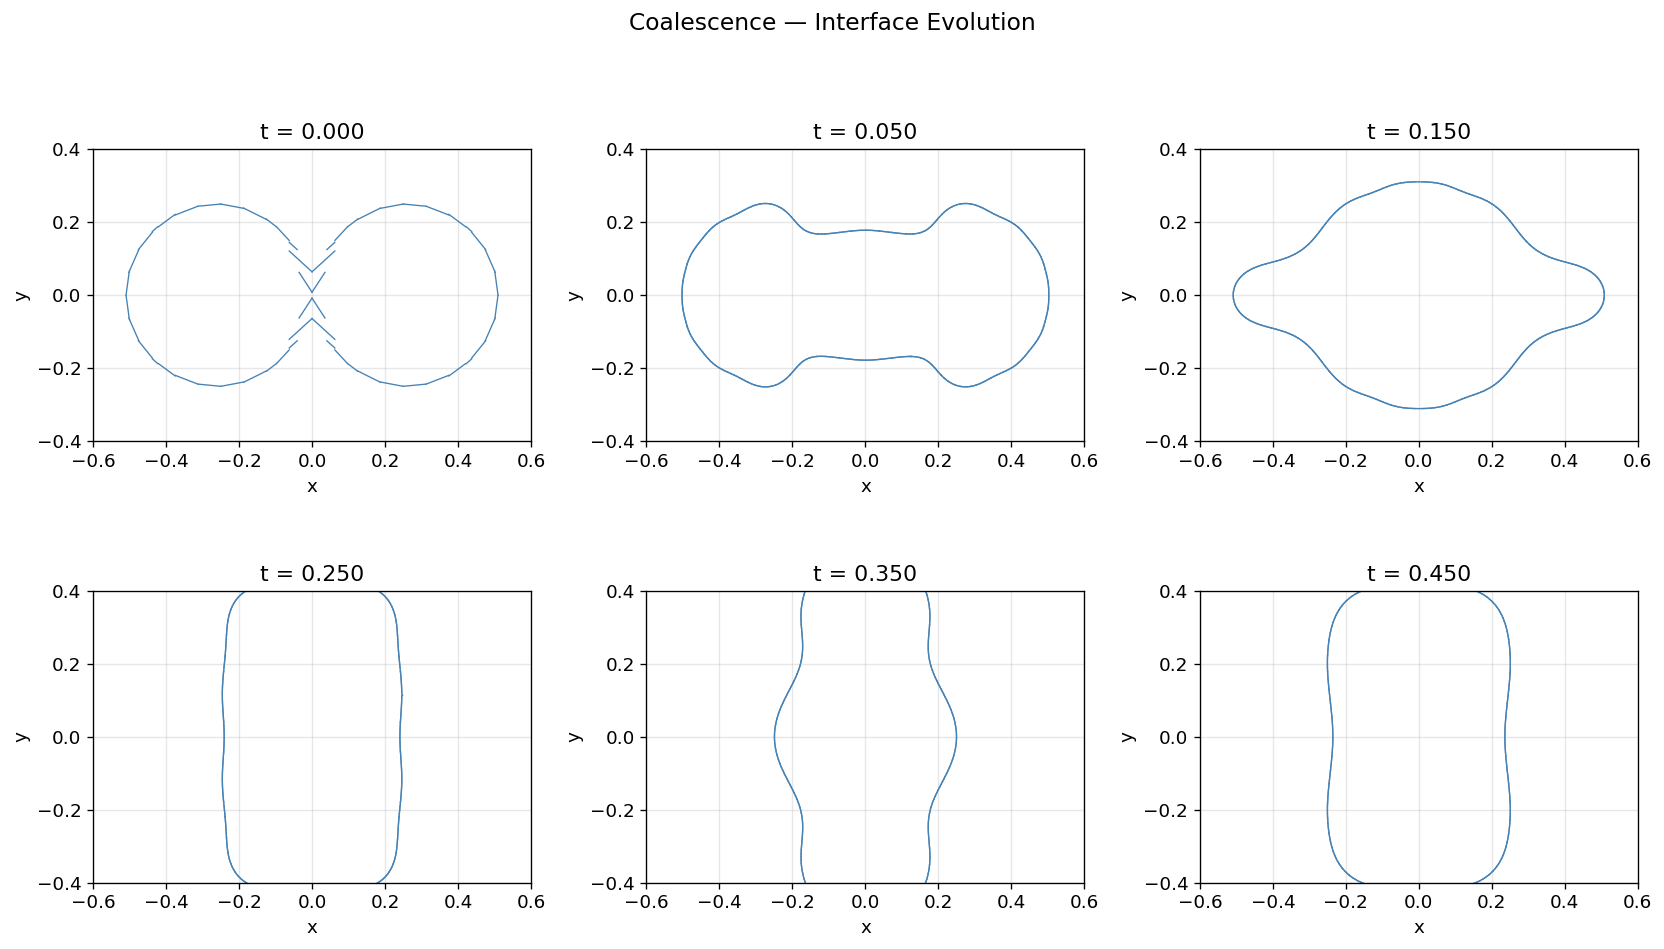

In [21]:
# --- Interface snapshots ---
files = sorted(data_dir.glob("interface-*.dat"))

if files:
    indices = np.linspace(0, len(files) - 1, min(6, len(files)), dtype=int)
    selected = [files[i] for i in indices]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for ax, fpath in zip(axes, selected):
        segments = load_facets(fpath)
        for seg in segments:
            if seg.shape[0] >= 2:
                ax.plot(seg[:, 0], seg[:, 1], "steelblue", lw=0.8)

        t_label = fpath.stem.replace("interface-", "t = ")
        ax.set_title(t_label)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(-0.4, 0.4)
        ax.set_aspect("equal")

    for ax in axes[len(selected):]:
        ax.set_visible(False)

    fig.suptitle("Coalescence — Interface Evolution", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ No interface files found in {data_dir}")
    print("  Run 'make case3' first.")